# 🏔️ **Práctica Final de Métodos y Tecnologías Modernas de Procesamiento de Datos Espaciales**

## Tema: Análisis Glaciar y Retroceso Cuantificado

### Autor: Luis Alberto Hernández Roselló

### Universidad de las Ciencias Informáticas

---

### 1. Configuración e Inicialización
Se configura el entorno de Python, instalan las librerías necesarias e inicializa la API de Google Earth Engine.

In [28]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    PROJECT_ID = 'vigitech-auth'
    ee.Initialize(project=PROJECT_ID)
    print("GEE inicializado correctamente.")
except Exception as e:
    print(f"Error inicializando GEE: {e}. Intentando autenticación...")
    # Si falla, autenticar y luego inicializar con el proyecto
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print("GEE autenticado e inicializado correctamente.")

GEE inicializado correctamente.


### 2. Definición de Parámetros y Región de Estudio
Se establecen variables globales (ROI, fechas, bandas de clasificación) para la reproducibilidad y fácil modificación del estudio.

In [29]:
YEAR_REF = 2000
YEAR_CLASSIFY = 2024

DATE_START_REF = f'{YEAR_REF}-02-01'
DATE_END_REF = f'{YEAR_REF}-03-31'

DATE_START_COMP = f'{YEAR_CLASSIFY}-01-01'
DATE_END_COMP = f'{YEAR_CLASSIFY}-03-31'

CLOUD_COVER_MAX = 10  # equivalente a 10%

# Región de Interés: Andes Centrales de Chile
ROI = ee.Geometry.Rectangle([-70.5, -33.5, -69.5, -32.5])

CLASS_PROPERTY = 'class'

INPUT_BANDS = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'NDSI',
               'NDWI', 'Temp', 'Elev', 'Slope', 'Aspect']

### 3. Funciones de Preprocesamiento y Homologación
Se definen las herramientas para normalizar Landsat 7 (2000) y Landsat 8/9 (2024), haciéndolos comparables:

- **Limpieza**: Eliminación de nubes/sombras y escalado de valores a reflectancia real.

- **Homologación**: Remapeo de bandas de Landsat 7 para que su estructura sea idéntica a Landsat 8/9, evitando errores en el modelo.

- **Índices (*Features*)**: Cálculo de NDSI (nieve/hielo) y NDWI (agua) para mejorar la clasificación.

- **Muestreo**: Creación de un buffer (área pequeña) alrededor de los puntos para capturar mejor la firma espectral.

In [30]:
def maskL7sr(image):
    """Estandariza Landsat 7 para que sea compatible con el modelo de L8/L9."""

    # 1. Seleccionar bandas originales de L7
    # L7 no tiene banda costera, así que mapeamos:
    # SR_B1 (Blue) -> B1 y B2 del modelo
    # SR_B2 (Green) -> B3
    # SR_B3 (Red) -> B4
    # SR_B4 (NIR) -> B5
    # SR_B5 (SWIR1) -> B6
    # SR_B7 (SWIR2) -> B7

    optical = image.select(
        ['SR_B1', 'SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'], # Origen
        ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7']                      # Destino (Nuevos nombres)
    ).multiply(0.0000275).add(-0.2)

    # 2. Banda Térmica (L7 usa ST_B6 para temperatura)
    thermal = image.select(['ST_B6'], ['Temp']).multiply(0.00341802).add(149.0)

    # 3. Máscara de nubes
    qa = image.select('QA_PIXEL')
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))

    return optical.addBands(thermal).updateMask(mask)

def maskL8sr(image):
    """
    Máscara de nubes y sombras para Landsat C2 L2.
    Aplica factores de escala a bandas ópticas y térmicas de forma eficiente.
    """
    # 1. Definir bandas y factores
    # Bandas SR (Ópticas): B1-B7
    sr_bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    new_names = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7']

    # 2. Aplicar escala y offset a bandas ópticas (Reflectancia [0, 1])
    # Se hace en una sola línea para optimizar memoria en GEE
    optical_scaled = image.select(sr_bands).multiply(0.0000275).add(-0.2).rename(new_names)

    # 3. Escalar banda térmica (ST_B10) a Kelvin
    thermal_band = image.select('ST_B10').multiply(0.00341802).add(149.0).rename('Temp')

    # 4. Crear máscara de nubes y sombras usando la banda QA_PIXEL
    qa = image.select('QA_PIXEL')
    # Bit 3: Sombras de nubes, Bit 5: Nubes
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))

    # 5. Juntar todo: Ópticas + Térmica + Máscara
    # Usamos updateMask al final para que todas las bandas hereden la limpieza de nubes
    return optical_scaled.addBands(thermal_band).updateMask(mask)

def addFeatures(image):
    """Calcula índices NDSI y NDWI usando las bandas ya escaladas."""
    # NDSI: (Verde - SWIR1) / (Verde + SWIR1) -> (B3 - B6) / (B3 + B6)
    ndsi = image.normalizedDifference(['B3', 'B6']).rename('NDSI')

    # NDWI: (Verde - NIR) / (Verde + NIR) -> (B3 - B5) / (B3 + B5)
    ndwi = image.normalizedDifference(['B3', 'B5']).rename('NDWI')

    return image.addBands([ndsi, ndwi])

# Función para convertir puntos en polígonos de muestreo
BUFFER_DISTANCE = 45

def add_buffer_to_points(feature):
    """Aplica un búfer a un punto para crear un polígono de muestreo."""
    return feature.buffer(BUFFER_DISTANCE)

### 4. Carga de Datos y Generación de Mosaicos

Se configuran y procesan los datos satelitales y topográficos para los dos periodos de estudio:

- **Variables Topográficas:** Se genera un modelo digital de elevación (DEM) para extraer altitud, pendiente y aspecto, esenciales para filtrar falsos positivos en la clasificación.

- **Mosaico 2024 (Actual):** Unión de colecciones Landsat 8 y 9, filtradas por fecha, área y nubosidad, aplicando correcciones espectrales y cálculo de índices.

- **Mosaico 2000 (Referencia):** Procesamiento de Landsat 7 con homologación de bandas para permitir la comparación directa con los sensores modernos.

- **Reducción:** Ambas colecciones se reducen mediante la mediana para obtener imágenes libres de nubes y artefactos, listas para el análisis de cambio.

In [31]:
# 1. Cargar Colecciones Base
L8_COLLECTION_L2 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
L9_COLLECTION_L2 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
L7_COLLECTION_L2 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')

# 2. Cargar el DEM y calcular topografía (Común para ambos años)
elevation_image = ee.Image('USGS/SRTMGL1_003')
terrain = ee.Terrain.products(elevation_image) \
            .select(['elevation', 'slope', 'aspect'], ['Elev', 'Slope', 'Aspect']) \
            .clip(ROI)

# --- PROCESAMIENTO MOSAICO 2000 (Referencia) ---
comp_image_collection_2000 = L7_COLLECTION_L2 \
    .filterDate(DATE_START_REF, DATE_END_REF) \
    .filterBounds(ROI) \
    .filter(ee.Filter.lt('CLOUD_COVER', CLOUD_COVER_MAX)) \
    .map(maskL7sr) \
    .map(addFeatures)

mosaic_2000 = comp_image_collection_2000 \
    .sort('CLOUD_COVER') \
    .median() \
    .addBands(terrain) \
    .clip(ROI)

# --- PROCESAMIENTO MOSAICO 2024 (Fecha a evaluar) ---
comp_image_collection_2024 = L8_COLLECTION_L2.merge(L9_COLLECTION_L2) \
    .filterDate(DATE_START_COMP, DATE_END_COMP) \
    .filterBounds(ROI) \
    .filter(ee.Filter.lt('CLOUD_COVER', CLOUD_COVER_MAX)) \
    .map(maskL8sr) \
    .map(addFeatures)

mosaic_2024 = comp_image_collection_2024 \
    .sort('CLOUD_COVER') \
    .median() \
    .addBands(terrain) \
    .clip(ROI)

print(f"Mosaicos generados exitosamente.")
print(f"Bandas disponibles en 2000: {mosaic_2000.bandNames().getInfo()}")
print(f"Bandas disponibles en 2024: {mosaic_2024.bandNames().getInfo()}")

Mosaicos generados exitosamente.
Bandas disponibles en 2000: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'Temp', 'NDSI', 'NDWI', 'Elev', 'Slope', 'Aspect']
Bandas disponibles en 2024: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'Temp', 'NDSI', 'NDWI', 'Elev', 'Slope', 'Aspect']


### 5. Definición de ROIs y Muestreo *(Train/Test)*

Se automatiza la recolección de muestras de entrenamiento utilizando criterios físicos para garantizar datos de alta pureza:

- **Zonas de Control:** Se delimitan áreas de "Glaciar" (NDSI > 0.7 y Elevación > 3500m) y "Roca" (NDSI < 0.05 y Elevación < 3000m) para extraer píxeles representativos.

- **Muestreo Automático:** Se generan 500 puntos por clase para asegurar un dataset balanceado, eliminando sesgos hacia la clase mayoritaria.

- **División de Datos:** El conjunto total se divide aleatoriamente en **70% para entrenamiento** (ajuste del modelo) y **30% para prueba** (validación independiente de la precisión).

In [32]:
# 1. Definir áreas de entrenamiento "Puras" mediante umbrales físicos
def generate_samples_by_year(mosaic, year_prefix):
    """
    Devuelve muestras de entrenamiento para un año dado.
    """
    # Clase 1: Glaciar (NDSI alto y Elevación alta)
    glaciar_mask = mosaic.select('NDSI').gt(0.4).And(terrain.select('Elev').gt(3200))
    # Clase 0: Roca (NDSI bajo y Elevación baja)
    roca_mask = mosaic.select('NDSI').lt(0.05).And(terrain.select('Elev').lt(3000))

    glaciar_samples = mosaic.updateMask(glaciar_mask).sample(
        region=ROI, scale=30, numPixels=250, seed=42, geometries=True
    ).map(lambda f: f.set(CLASS_PROPERTY, 1).set('period', year_prefix))

    rock_samples = mosaic.updateMask(roca_mask).sample(
        region=ROI, scale=30, numPixels=250, seed=42, geometries=True
    ).map(lambda f: f.set(CLASS_PROPERTY, 0).set('period', year_prefix))

    return glaciar_samples.merge(rock_samples)

# Obtener muestras de ambos periodos
samples_2000 = generate_samples_by_year(mosaic_2000, "2000")
samples_2024 = generate_samples_by_year(mosaic_2024, "2024")

# 3. Unir y mezclar los datos
all_samples = samples_2000.merge(samples_2024).randomColumn('random')

# 4. Dividir en Entrenamiento (70%) y Prueba (30%) de forma aleatoria
training_data = all_samples.filter(ee.Filter.lt('random', 0.7))
testing_data = all_samples.filter(ee.Filter.gte('random', 0.7))

print(f"Píxeles de entrenamiento (Automáticos): {training_data.size().getInfo()}")
print(f"Píxeles de prueba (Automáticos): {testing_data.size().getInfo()}")

Píxeles de entrenamiento (Automáticos): 109
Píxeles de prueba (Automáticos): 40


### **6. Entrenamiento del Modelo y Clasificación**

Se ejecuta el aprendizaje supervisado y la generación del mapa temático final:

- ***Random Forest:*** Se entrena el algoritmo con 250 árboles, utilizando las bandas espectrales, índices y variables topográficas como predictores.

- **Filtros Físicos:** Se aplican máscaras de seguridad para mejorar la precisión, limitando la clasificación a zonas con elevación > 3000 msnm y pendientes < 40°, descartando errores en valles o paredes verticales.

- **Clasificación:** El modelo procesa el mosaico completo para identificar la extensión actual del hielo y la nieve.

In [33]:
TREE_CANT = 250

# Entrenar el clasificador Random Forest
classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=TREE_CANT,
    variablesPerSplit=3,
    minLeafPopulation=2,
    seed=42
).train(
    features=training_data,
    classProperty=CLASS_PROPERTY,
    inputProperties=INPUT_BANDS
)

# Máscara de Seguridad Física (Indispensable en los Andes)
elevation_mask = terrain.select('Elev').gt(3000)
slope_mask = terrain.select('Slope').lt(40) # Los glaciares no suelen estar en paredes verticales

# Clasificación Final
classified_image_2000 = mosaic_2000.select(INPUT_BANDS) \
                    .classify(classifier) \
                    .updateMask(elevation_mask) \
                    .updateMask(slope_mask)

classified_image_2024 = mosaic_2024.select(INPUT_BANDS) \
                    .classify(classifier) \
                    .updateMask(elevation_mask) \
                    .updateMask(slope_mask)

print(f"Clasificador RF entrenado con {TREE_CANT} árboles y aplicado con filtros físicos.")

Clasificador RF entrenado con 250 árboles y aplicado con filtros físicos.


### 7. Evaluación de Precisión

Se valida el desempeño estadístico del modelo utilizando datos que el algoritmo no vio durante el entrenamiento:

- **Matriz de Confusión:** Cruce de datos entre la realidad observada (prueba) y la predicción del modelo para identificar errores de omisión y comisión.

- **Precisión Global y Kappa:** Indicadores del éxito general del modelo, donde el Coeficiente Kappa ajusta la precisión obtenida por el azar.

- **Exactitud Productor/Consumidor:** Evaluación específica para la clase "Glaciar", midiendo qué tan bien el modelo identifica el hielo (*Recall*) y qué tan "puro" es el resultado final (Precision).


--- Evaluación de Precisión ---


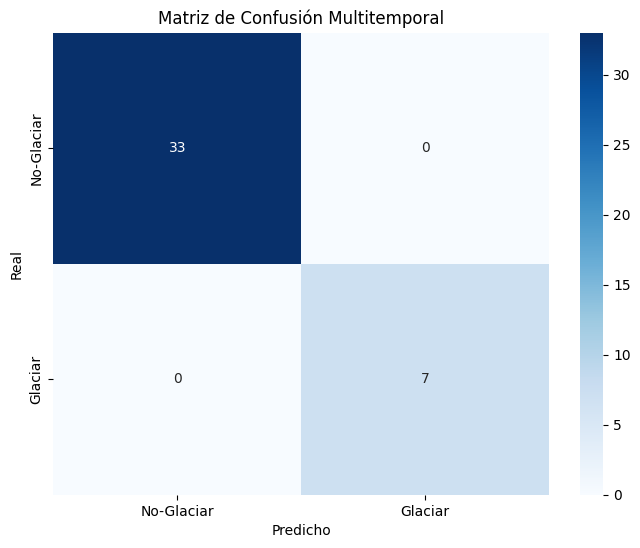


Precisión Global (Overall Accuracy): 1.0000
Coeficiente Kappa: 1.0000

Precisión del Productor (Recall/Sensibilidad - Glaciar):
  Clase 1 (Glaciar): 1.0000

Precisión del Consumidor (Precision/Pureza - Glaciar):
  Clase 1 (Glaciar): 1.0000


In [34]:
# 1. Clasificar el conjunto de prueba utilizando el modelo entrenado.
validated = testing_data.classify(classifier)

# 2. Generar la Matriz de Confusión
confusion_matrix = validated.errorMatrix(CLASS_PROPERTY, 'classification')

print('\n--- Evaluación de Precisión ---')

import seaborn as sns

# Convertir matriz a un array de numpy para graficar
matrix_array = confusion_matrix.getInfo()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-Glaciar', 'Glaciar'],
            yticklabels=['No-Glaciar', 'Glaciar'])
plt.title('Matriz de Confusión Multitemporal')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# 3. Cálculo de Métricas (basado en la Matriz de Confusión)

# Precisión Global (Overall Accuracy)
overall_accuracy = confusion_matrix.accuracy().getInfo()
print(f"\nPrecisión Global (Overall Accuracy): {overall_accuracy:.4f}")

# Coeficiente Kappa
kappa = confusion_matrix.kappa().getInfo()
print(f"Coeficiente Kappa: {kappa:.4f}")

# Precisión del Productor (Recall/Sensibilidad) - Glaciar (Clase 1)
producer_accuracy = confusion_matrix.producersAccuracy().getInfo()
# producer_accuracy es [[Clase 0], [Clase 1]], por lo que [1][0] es correcto
producer_acc_glacier = producer_accuracy[1][0]
print("\nPrecisión del Productor (Recall/Sensibilidad - Glaciar):")
print(f"  Clase 1 (Glaciar): {producer_acc_glacier:.4f}")

# Precisión del Consumidor (Clase 1)
consumer_accuracy = confusion_matrix.consumersAccuracy().getInfo()

if isinstance(consumer_accuracy[0], list):
    # La estructura es [[v0, v1]]. Usamos el índice [0] para la lista interior y [1] para el Glaciar.
    consumer_acc_glacier = consumer_accuracy[0][1]
else:
    # La estructura es [v0, v1]. Usamos el índice [1] para el Glaciar.
    consumer_acc_glacier = consumer_accuracy[1]

print("\nPrecisión del Consumidor (Precision/Pureza - Glaciar):")
print(f"  Clase 1 (Glaciar): {consumer_acc_glacier:.4f}")

### 8. Cuantificación de Área y Análisis Estadístico

Se calcula la superficie total de la clase de interés y se genera la representación gráfica de los resultados:

- **Cálculo Geométrico:** Se utiliza la función `pixelArea()` para obtener la superficie real de cada píxel, corrigiendo distorsiones por latitud, y se suma exclusivamente para la clase "Glaciar".

- **Conversión de Unidades:** El resultado se transforma de metros cuadrados a **kilómetros cuadrados (km²)** para facilitar su interpretación científica.

In [46]:
# 1. Cuantificación de Área (m²)
def get_area(img):
    area = img.eq(1).selfMask().multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ROI,
        scale=30,
        maxPixels=1e13
    ).get('classification')

    return ee.Number(ee.Algorithms.If(area, area, 0)).divide(1e6)

area_classified_km2_2000 = get_area(classified_image_2000).getInfo()
area_classified_km2_2024 = get_area(classified_image_2024).getInfo()

print(f"\nÁrea glaciar clasificada ({YEAR_REF}): {area_classified_km2_2000:,.2f} km²")
print(f"\nÁrea glaciar clasificada ({YEAR_CLASSIFY}): {area_classified_km2_2024:,.2f} km²")
print(f"\nÁrea total clasificada: {sum([area_classified_km2_2024, area_classified_km2_2000]):,.2f} km²")


Área glaciar clasificada (2000): 1,059.36 km²

Área glaciar clasificada (2024): 355.31 km²

Área total clasificada: 1,414.67 km²


### 9. Visualización Cartográfica Interactiva

Se genera el producto cartográfico final integrando los resultados del modelo y los datos de validación:

- **Mapa Clasificado:** Visualización de la extensión glaciar en blanco sobre un fondo de color tierra (`sienna`), permitiendo identificar la cobertura de hielo de forma clara.

- **Contexto Espectral:** Se añade una capa en **Color Real** (RGB 432) de Landsat para contrastar la clasificación con la apariencia visual del terreno.

- **Superposición de ROIs:** Inclusión de los puntos de **entrenamiento (verde)** y **prueba (rojo)** para verificar espacialmente la coherencia del modelo frente a las muestras recolectadas.

- **Interactividad:** Uso de controles de capa y transparencia para explorar la relación entre la topografía, las imágenes satelitales y el mapa temático generado.

In [36]:
# Visualización del Mapa
Map_classifier_result = geemap.Map(center=[-33.13, -69.81], zoom=9)
Map_classifier_result.add_basemap('HYBRID')

# Paleta de colores para el mapa clasificado (0: No Glaciar, 1: Glaciar)
vis_params_glacier_rf_2000 = {'min': 0, 'max': 1, 'palette': ['gray', 'blue']}
vis_params_glacier_rf_2024 = {'min': 0, 'max': 1, 'palette': ['gray', 'cyan']}

# Capa de Clasificación
Map_classifier_result.addLayer(
    classified_image_2000,
    vis_params_glacier_rf_2000,
    f'Glaciar RF Clasificado ({YEAR_REF})',
    True,
    opacity=0.8
)

# Capa de Clasificación
Map_classifier_result.addLayer(
    classified_image_2024,
    vis_params_glacier_rf_2024,
    f'Glaciar RF Clasificado ({YEAR_CLASSIFY})',
    True,
    opacity=0.8
)

# Capa de Color Real (para contexto)
# Se seleccionan B4, B3, B2 que ya están escaladas (0-1)
Map_classifier_result.addLayer(
    mosaic_2024.select(['B4', 'B3', 'B2']),
    {'min': 0.05, 'max': 0.35, 'gamma': 1.5},
    f'Landsat 8/9 Color Real ({YEAR_CLASSIFY})',
    False
)

# 1. Definición de estilos para los ROIs (mantener estos)
roi_vis_params_train = {'color': 'green', 'pointSize': 5}
roi_vis_params_test = {'color': 'red', 'pointSize': 5}

# 2. Añadir capas usando la FeatureCollection y el diccionario de estilo directamente

# Añadir ROIs de Entrenamiento
Map_classifier_result.addLayer(
    training_data,
    roi_vis_params_train,
    'ROIs de Entrenamiento',
    True # Visible
)

# Añadir ROIs de Prueba/Validación
Map_classifier_result.addLayer(
    testing_data,
    roi_vis_params_test,
    'ROIs de Prueba',
    True # Visible
)

Map_classifier_result.addLayerControl()
Map_classifier_result

Map(center=[-33.13, -69.81], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

### 10. Análisis de Cambio Temporal y Detección de Pérdida

Esta sección constituye el núcleo del estudio, donde se cuantifica la evolución de la masa glaciar mediante una comparación multitemporal:

- **Validación Condicional:** El análisis solo se ejecuta si el **Índice Kappa** supera el umbral de 0.80, asegurando que las conclusiones se basen en un modelo de alta confiabilidad.

- **Clasificación Histórica:** Se aplica el modelo entrenado con datos modernos al mosaico del año 2000. Al utilizar el mismo algoritmo (*Random Forest*), se garantiza que la comparación sea consistente y no dependa de criterios distintos entre años.

- **Cálculo de Retroceso:** Se determina el área para ambos periodos y se calcula la **pérdida neta** en kilómetros cuadrados y el **porcentaje de cambio**, permitiendo dimensionar el impacto del cambio climático en la zona de estudio.

- **Balance Glaciar:** Los resultados se presentan en un gráfico comparativo que facilita la interpretación visual de la reducción drástica de la superficie de hielo.

In [41]:
# --- EVALUACIÓN DE CALIDAD ---
UMBRAL_KAPPA = 0.80

if kappa > UMBRAL_KAPPA:
    print(f"✅ Calidad excelente (Kappa: {kappa:.4f}). Procediendo con el análisis temporal...")

    perdida_neta = area_classified_km2_2000 - area_classified_km2_2024
    cambio_porcentual = (perdida_neta / area_classified_km2_2000) * 100

    # --- VISUALIZACIÓN DE RESULTADOS ---
    print(f"\n📊 RESUMEN DE CAMBIO GLACIAR ({YEAR_REF} - {YEAR_CLASSIFY})")
    print(f"Área {YEAR_REF}: {area_classified_km2_2000:.2f} km²")
    print(f"Área {YEAR_CLASSIFY}: {area_classified_km2_2024:.2f} km²")
    print(f"Pérdida: {perdida_neta:.2f} km² ({cambio_porcentual:.1f}%)")

    # Gráfico Comparativo
    df_comparativo = pd.DataFrame({
        'Año': [str(YEAR_REF), str(YEAR_CLASSIFY)],
        'Área (km²)': [area_classified_km2_2000, area_classified_km2_2024]
    })
    df_comparativo.plot(kind='bar', x='Año', color=['blue', 'red'], legend=False)
    plt.title('Pérdida de Masa Glaciar (2000-2024)')
    plt.ylabel('km²')
    plt.show()

else:
    print(f"⚠️ Calidad insuficiente (Kappa: {kappa:.4f}). Revisa el entrenamiento antes de proceder.")

✅ Calidad excelente (Kappa: 1.0000). Procediendo con el análisis temporal...


AttributeError: 'float' object has no attribute 'eq'

### 11. Comparación Visual de Retroceso Glaciar

Esta celda genera el mapa final de contraste para visualizar espacialmente dónde ocurrió la pérdida de hielo:

- **Superposición Temporal:** Se añaden las capas de ambos periodos sobre un mapa base híbrido. El color **Cian (#00FFFF)** representa la extensión del año 2000, mientras que el **Blanco** muestra el área remanente en 2024.

- **Identificación de Pérdida:** Visualmente, las áreas que se mantienen en color cian pero no están cubiertas por blanco indican el retroceso de las lenguas glaciares y la pérdida de masa acumulada en 24 años.

- **Barra de Colores:** Se incluye una guía horizontal para diferenciar las clases temporales, facilitando la interpretación cartográfica del producto final.

- **Transparencia Estratégica:** Se ajusta la opacidad de las capas para permitir la visualización de la topografía subyacente, ayudando a entender la relación entre el relieve y la persistencia del hielo.

In [40]:
# 1. Crear el mapa base
Map_glaciar_analysis = geemap.Map(basemap='HYBRID', center=[-33.13, -69.81], zoom=10)
Map_glaciar_analysis.add_basemap('HYBRID')

# 2. Glaciar en el año 2000 (Cian)
Map_glaciar_analysis.addLayer(
    classified_image_2000.eq(1).selfMask(),
    {'palette': ['#00FFFF']},
    f'Extensión Glaciar {YEAR_REF}',
    True,
    opacity=0.6
)

# 3. Glaciar en el año 2024 (Blanco)
Map_glaciar_analysis.addLayer(
    classified_image_2024.eq(1).selfMask(),
    {'palette': ['white']},
    f'Extensión Glaciar {YEAR_CLASSIFY}',
    True,
    opacity=0.9
)

vis_params_legend = {
    'min': 0,
    'max': 1,
    'palette': ['#00FFFF', 'white']
}

Map_glaciar_analysis.add_colorbar(
    vis_params=vis_params_legend,
    label="Cian: 2000 | Blanco: 2024",
    orientation="horizontal",
    layer_name="Comparación Temporal"
)

Map_glaciar_analysis.addLayerControl()
Map_glaciar_analysis

Map(center=[-33.13, -69.81], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…